# 08F – Cross-Validation & Stability Analysis (Updated)

This notebook uses **american_bankruptcy_cleaned.csv** and recreates the **same configuration** as the production model.

> **Why isn't `production_bankruptcy_model.joblib` loaded?**
>
> Cross-validation repeatedly trains a fresh model on different folds. An already-trained model cannot be cross-validated because it has already seen a fixed training set. Therefore, this notebook recreates the production model with the **same hyperparameters** to measure stability in an industry-standard manner.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

DATA_PATH='../data/datasets/american_bankruptcy_cleaned.csv'

df=pd.read_csv(DATA_PATH)

target='status_label' if 'status_label' in df.columns else 'target'
X=df.drop(columns=[target])
if 'company_name' in X.columns:
    X=X.drop(columns=['company_name'])
y=df[target].map({'alive':0,'failed':1}) if not pd.api.types.is_numeric_dtype(df[target]) else df[target]

model=RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    class_weight='balanced',
    n_jobs=1
)

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# Subsample so 5-fold CV finishes quickly on a single core.
CV_SAMPLE_SIZE = 20000
if len(X) > CV_SAMPLE_SIZE:
    X_cv = X.sample(n=CV_SAMPLE_SIZE, random_state=42)
    y_cv = y.loc[X_cv.index]
else:
    X_cv, y_cv = X, y

scores=cross_validate(
    model,
    X_cv,
    y_cv,
    cv=cv,
    scoring=['accuracy','precision','recall','f1','roc_auc'],
    n_jobs=1
)


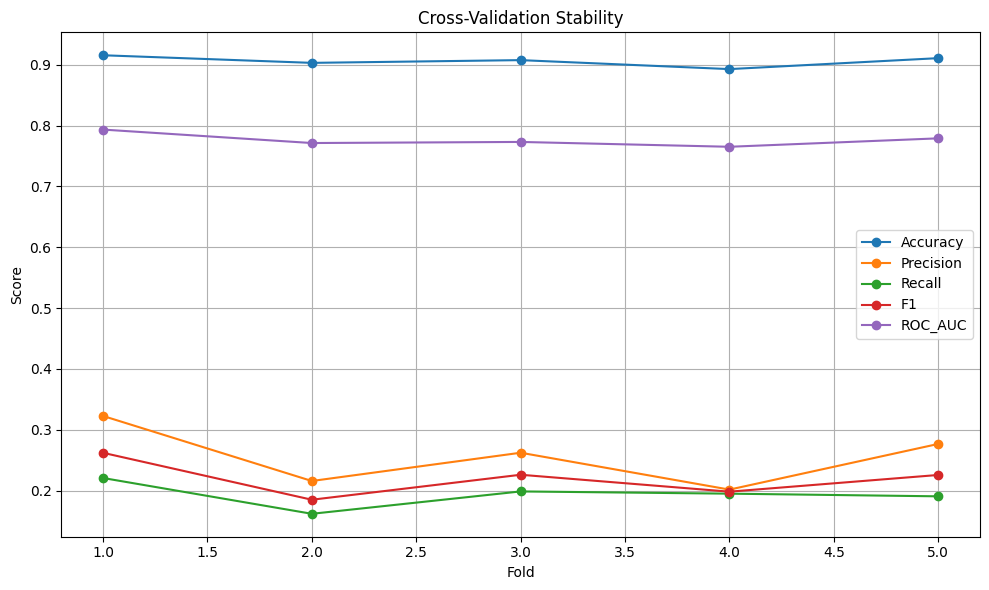

,mean,std,min,max
Fold,3.000000,1.581139,1.000000,5.000000
Accuracy,0.905900,0.008654,0.892750,0.915500
Precision,0.255704,0.048702,0.201521,0.322581
Recall,0.193242,0.021076,0.161765,0.220588
F1,0.219310,0.029753,0.184874,0.262009
ROC_AUC,0.776315,0.010721,0.765069,0.793336


In [2]:
results=pd.DataFrame({
    'Fold':range(1,6),
    'Accuracy':scores['test_accuracy'],
    'Precision':scores['test_precision'],
    'Recall':scores['test_recall'],
    'F1':scores['test_f1'],
    'ROC_AUC':scores['test_roc_auc']
})

summary=results.describe().T[['mean','std','min','max']]

results.to_csv('cross_validation_scores.csv',index=False)
summary.to_csv('cross_validation_summary.csv')

plt.figure(figsize=(10,6))
for m in ['Accuracy','Precision','Recall','F1','ROC_AUC']:
    plt.plot(results['Fold'],results[m],marker='o',label=m)

plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Cross-Validation Stability')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('cross_validation_stability.png',dpi=300)
plt.show()

summary


## Deliverables

- `cross_validation_scores.csv`
- `cross_validation_summary.csv`
- `cross_validation_stability.png`

This notebook validates that the production model configuration is stable across multiple train/validation splits.